<a href="https://colab.research.google.com/github/tanyaverma20/Tredence-Analytics/blob/main/Self_Pruning_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-Pruning Neural Network on CIFAR-10

What this notebook demonstrates:
- A CNN + prunable-FC hybrid that learns to remove its own weights during training
- Learnable sigmoid gates applied element-wise to each weight (soft pruning)
- L1 regularisation on gate values to encourage sparsity
- Three λ experiments to map the accuracy ↔ sparsity trade-off

## Setup & Dependencies

In [1]:
# Install dependencies
!pip install torch torchvision matplotlib numpy

import os, json, copy, warnings, math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')
os.makedirs('./results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


## PrunableLinear Layer

Each weight w_ij is multiplied by gate_ij = sigmoid(score_ij) — a free learned scalar.

- Gates initialised to 0 → sigmoid(0) = 0.5 (neutral start, half-open)
- L1 penalty on gates pushes score → −∞ → gate → 0 → weight effectively removed
- Gradients flow through both weight and gate_scores simultaneously via autograd

Unlike L2 regularisation (gradient ∝ gate magnitude), L1 applies a constant gradient
of magnitude λ regardless of how small the gate already is — driving it all the way to zero.

In [2]:
class PrunableLinear(nn.Module):
    """
    Linear layer with a learnable sigmoid gate per weight.
    When gate → 0, that weight is effectively pruned from the network.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Weight matrix — Kaiming uniform (best for ReLU)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        # Bias
        if bias:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            self.bias = nn.Parameter(torch.empty(out_features))
            nn.init.uniform_(self.bias, -bound, bound)
        else:
            self.register_parameter('bias', None)

        # Gate scores — initialised to 0 so sigmoid(0)=0.5 (neutral start)
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Raw scores → [0, 1] gates
        gates = torch.sigmoid(self.gate_scores)      # [out, in]
        # 2. Element-wise mask each weight by its gate
        pruned_weights = self.weight * gates          # [out, in]
        # 3. Standard linear projection
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self) -> torch.Tensor:
        """Gate values in [0, 1]."""
        return torch.sigmoid(self.gate_scores)

    def get_sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of this layer's gates below threshold."""
        gates = self.get_gates()
        return (gates < threshold).sum().item() / gates.numel()


print('PrunableLinear defined.')

PrunableLinear defined.


## Network Architecture

```
Input [3 x 32 x 32]
  Conv2d(3->32, 3x3) + BatchNorm + ReLU + MaxPool  ->  [32 x 16 x 16]
  Conv2d(32->64, 3x3) + BatchNorm + ReLU + MaxPool ->  [64 x 8 x 8] = 4096 features
  PrunableLinear(4096 -> 512) + ReLU + Dropout(0.3)
  PrunableLinear(512  -> 256) + ReLU + Dropout(0.3)
  PrunableLinear(256  -> 128) + ReLU
  PrunableLinear(128  ->  10)   <- logits
```

The CNN frontend extracts spatial features (non-prunable).
The prunable FC backend learns which feature interactions matter.

In [3]:
class SelfPruningNet(nn.Module):
    """
    CNN feature extractor + prunable fully-connected classifier.

    hidden_sizes : widths of prunable FC layers
    num_classes  : output classes (10 for CIFAR-10)
    dropout_p    : dropout probability applied between FC layers
    """

    def __init__(
        self,
        hidden_sizes: list = [512, 256, 128],
        num_classes:  int  = 10,
        dropout_p:    float = 0.3
    ):
        super().__init__()

        # CNN frontend (fixed, not prunable)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )  # -> [B, 64, 8, 8]

        fc_input = 64 * 8 * 8  # 4096

        # Prunable FC backend
        fc_blocks, prev = [], fc_input
        for i, h in enumerate(hidden_sizes):
            fc_blocks.append(PrunableLinear(prev, h))
            fc_blocks.append(nn.ReLU(inplace=True))
            if i < len(hidden_sizes) - 1:          # dropout between hidden layers
                fc_blocks.append(nn.Dropout(p=dropout_p))
            prev = h
        fc_blocks.append(PrunableLinear(prev, num_classes))  # logit head
        self.classifier = nn.Sequential(*fc_blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)           # CNN pass
        x = x.view(x.size(0), -1)      # flatten -> [B, 4096]
        return self.classifier(x)       # FC pass  -> [B, 10]

    # ---- Sparsity helpers (encapsulated inside model) -----------------

    def get_sparsity_loss(self) -> torch.Tensor:
        """L1 norm of ALL gate values — differentiable, used in training loss."""
        total = torch.tensor(0.0, device=next(self.parameters()).device)
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                total = total + m.get_gates().sum()
        return total

    def get_sparsity_level(self, threshold: float = 1e-2) -> float:
        """Overall % of gates below threshold across the whole network."""
        pruned = total = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates   = m.get_gates()
                pruned += (gates < threshold).sum().item()
                total  += gates.numel()
        return 100.0 * pruned / total if total else 0.0

    def get_layer_sparsities(self, threshold: float = 1e-2) -> list:
        """Per-layer sparsity percentages."""
        return [
            round(m.get_sparsity(threshold) * 100, 1)
            for m in self.modules() if isinstance(m, PrunableLinear)
        ]


# Quick shape sanity check
_m = SelfPruningNet()
assert _m(torch.randn(2, 3, 32, 32)).shape == (2, 10)
total_params = sum(p.numel() for p in _m.parameters())
print(f'SelfPruningNet defined.  Total parameters: {total_params:,}')
del _m

SelfPruningNet defined.  Total parameters: 4,545,034


## Gradient Flow Verification

Before training, confirm both weight and gate_scores receive gradients.
If either shows False, the pruning mechanism is broken.

In [4]:
def verify_gradient_flow(device: torch.device) -> None:
    print('=' * 55)
    print('   Gradient Flow Verification')
    print('=' * 55)

    probe  = SelfPruningNet().to(device)
    images = torch.randn(8, 3, 32, 32, device=device)
    labels = torch.randint(0, 10, (8,), device=device)

    out  = probe(images)
    loss = F.cross_entropy(out, labels) + 1e-4 * probe.get_sparsity_loss()
    loss.backward()

    all_ok = True
    for name, m in probe.named_modules():
        if isinstance(m, PrunableLinear):
            w_ok = m.weight.grad is not None
            g_ok = m.gate_scores.grad is not None
            tag  = 'OK  ' if (w_ok and g_ok) else 'FAIL'
            print(f'  [{tag}] {name:30s}  weight.grad={w_ok}  gate_scores.grad={g_ok}')
            if not (w_ok and g_ok):
                all_ok = False

    print('=' * 55)
    status = 'ALL GRADIENTS FLOWING CORRECTLY' if all_ok else 'GRADIENT ISSUE DETECTED'
    print(f'   Result: {status}')
    print('=' * 55)
    del probe


verify_gradient_flow(device)

   Gradient Flow Verification
  [OK  ] classifier.0                    weight.grad=True  gate_scores.grad=True
  [OK  ] classifier.3                    weight.grad=True  gate_scores.grad=True
  [OK  ] classifier.6                    weight.grad=True  gate_scores.grad=True
  [OK  ] classifier.8                    weight.grad=True  gate_scores.grad=True
   Result: ALL GRADIENTS FLOWING CORRECTLY


## Data Loading

- Train (45k): RandomCrop(32, pad=4) + RandomHorizontalFlip + Normalize
- Val (5k): Normalize only — no augmentation for unbiased evaluation
- Test (10k): Official CIFAR-10 test set, untouched until final evaluation

In [5]:
def get_cifar10_loaders(batch_size=128, val_fraction=0.1, num_workers=2):
    MEAN = (0.4914, 0.4822, 0.4465)
    STD  = (0.2023, 0.1994, 0.2010)

    train_tfm = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD)
    ])
    eval_tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD)
    ])

    full_train = datasets.CIFAR10('./data', train=True,  download=True,  transform=train_tfm)
    full_val   = datasets.CIFAR10('./data', train=True,  download=False, transform=eval_tfm)
    test_set   = datasets.CIFAR10('./data', train=False, download=True,  transform=eval_tfm)

    n_total = len(full_train)
    n_val   = int(n_total * val_fraction)
    indices = torch.randperm(n_total).tolist()

    train_loader = DataLoader(Subset(full_train, indices[n_val:]),
                              batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(Subset(full_val,   indices[:n_val]),
                              batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set,
                              batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f'Train: {n_total - n_val:,}  |  Val: {n_val:,}  |  Test: {len(test_set):,}')
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_cifar10_loaders()

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Train: 45,000  |  Val: 5,000  |  Test: 10,000


## Training Engine

Total loss:
```
L = CrossEntropyLoss(logits, labels)  +  λ * sum(sigmoid(gate_scores))
```

Early stopping: halts if val accuracy doesn't improve for patience consecutive epochs;
best checkpoint is automatically restored.

Cosine LR annealing: smoothly decays lr from 1e-3 → 1e-5 over training.

In [6]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits      = model(images)
        total_loss += F.cross_entropy(logits, labels).item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return {'accuracy': 100.0 * correct / total,
            'loss':     total_loss / len(loader)}


def train_model(lambda_sparse, train_loader, val_loader, device,
                num_epochs=50, lr=1e-3, patience=10):
    """
    Train SelfPruningNet with a given sparsity coefficient.
    Returns (best_model, history_dict).
    """
    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    history        = defaultdict(list)
    best_val_acc   = -1.0
    best_state     = None
    patience_count = 0

    for epoch in range(1, num_epochs + 1):
        # ---- Training pass -----------------------------------------
        model.train()
        run_ce = run_sp = run_tot = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            logits  = model(images)
            ce_loss = F.cross_entropy(logits, labels)
            sp_loss = lambda_sparse * model.get_sparsity_loss()
            loss    = ce_loss + sp_loss

            loss.backward()
            optimizer.step()

            run_ce  += ce_loss.item()
            run_sp  += sp_loss.item()
            run_tot += loss.item()

        scheduler.step()
        nb = len(train_loader)
        history['train_ce'].append(run_ce / nb)
        history['train_sp'].append(run_sp / nb)
        history['train_loss'].append(run_tot / nb)

        # ---- Validation pass ---------------------------------------
        val   = evaluate(model, val_loader, device)
        va    = val['accuracy']
        history['val_acc'].append(va)
        history['val_loss'].append(val['loss'])
        history['sparsity'].append(model.get_sparsity_level())

        # ---- Early stopping ----------------------------------------
        if va > best_val_acc:
            best_val_acc   = va
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  [Early stop @ epoch {epoch}]  Best val acc: {best_val_acc:.2f}%')
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep {epoch:3d}/{num_epochs} | '
                  f'Loss {run_tot/nb:.4f} '
                  f'(CE={run_ce/nb:.4f} SP={run_sp/nb:.4f}) | '
                  f'ValAcc {va:.2f}% | '
                  f'Sparsity {history["sparsity"][-1]:.1f}%')

    model.load_state_dict(best_state)
    return model, dict(history)


print('Training engine defined.')

Training engine defined.


## Visualisation Helpers

In [7]:
def plot_training_curves(history, lam, save_path=None):
    epochs = range(1, len(history['val_acc']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Training Curves  (lambda={lam:.0e})', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, history['train_ce'],  label='Train CE')
    axes[0].plot(epochs, history['val_loss'],  label='Val loss', linestyle='--')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

    axes[1].plot(epochs, history['val_acc'], color='green')
    axes[1].set_title('Validation Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 100)

    axes[2].plot(epochs, history['sparsity'], color='orange')
    axes[2].set_title('Network Sparsity (%)'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 100)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_gate_distribution(model, lam, result, save_path=None):
    all_gates = torch.cat([
        m.get_gates().detach().cpu().flatten()
        for m in model.modules() if isinstance(m, PrunableLinear)
    ]).numpy()

    pruned    = (all_gates < 0.01).sum()
    surviving = (all_gates >= 0.01).sum()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(all_gates, bins=100, color='steelblue', edgecolor='black', alpha=0.75)
    ax.axvline(0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold=0.01')
    ax.set_title(
        f'Gate Distribution  lambda={lam:.0e}  |  '
        f'Acc={result["test_accuracy"]:.2f}%  |  '
        f'Sparsity={result["sparsity"]:.1f}%', fontsize=10)
    ax.set_xlabel('Gate Value'); ax.set_ylabel('Count')
    ax.annotate(
        f'Pruned   : {pruned:,}\nSurviving: {surviving:,}',
        xy=(0.60, 0.80), xycoords='axes fraction', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    ax.legend()
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_summary_comparison(results, save_path=None):
    labels     = [f"lambda={r['lambda']:.0e}" for r in results]
    accuracies = [r['test_accuracy'] for r in results]
    sparsities = [r['sparsity']      for r in results]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    fig.suptitle('Accuracy vs Sparsity Trade-off', fontsize=13, fontweight='bold')

    x    = range(len(labels))
    bars = ax1.bar(x, accuracies, color='steelblue', alpha=0.75, label='Test Accuracy (%)')
    ax1.set_xticks(x); ax1.set_xticklabels(labels)
    ax1.set_ylabel('Test Accuracy (%)'); ax1.set_ylim(0, 100)
    for b, a in zip(bars, accuracies):
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f'{a:.1f}%', ha='center', fontsize=10, fontweight='bold')

    ax2 = ax1.twinx()
    ax2.plot(x, sparsities, 'ro--', lw=2, ms=8, label='Sparsity (%)')
    ax2.set_ylabel('Sparsity (%)', color='red'); ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='red')
    for xi, sp in zip(x, sparsities):
        ax2.text(xi, sp + 2, f'{sp:.1f}%', ha='center', color='red', fontsize=9)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper right')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Visualisation helpers defined.')

Visualisation helpers defined.


## Run All Experiments



  Experiment: lambda = 1e-05
  Ep   1/50 | Loss 12.0426 (CE=1.6601 SP=10.3825) | ValAcc 50.00% | Sparsity 0.0%
  Ep   5/50 | Loss 6.3774 (CE=1.0488 SP=5.3286) | ValAcc 68.02% | Sparsity 0.0%
  Ep  10/50 | Loss 3.8904 (CE=0.8804 SP=3.0101) | ValAcc 72.76% | Sparsity 0.0%
  Ep  15/50 | Loss 2.9162 (CE=0.7844 SP=2.1317) | ValAcc 74.44% | Sparsity 0.0%
  Ep  20/50 | Loss 2.4373 (CE=0.7254 SP=1.7118) | ValAcc 76.98% | Sparsity 0.0%
  Ep  25/50 | Loss 2.1588 (CE=0.6753 SP=1.4834) | ValAcc 78.58% | Sparsity 50.1%
  Ep  30/50 | Loss 1.9873 (CE=0.6348 SP=1.3525) | ValAcc 79.96% | Sparsity 50.6%
  Ep  35/50 | Loss 1.8944 (CE=0.6165 SP=1.2779) | ValAcc 80.48% | Sparsity 51.2%
  Ep  40/50 | Loss 1.8305 (CE=0.5923 SP=1.2382) | ValAcc 81.06% | Sparsity 51.7%
  Ep  45/50 | Loss 1.8014 (CE=0.5807 SP=1.2207) | ValAcc 81.38% | Sparsity 51.9%
  Ep  50/50 | Loss 1.7944 (CE=0.5789 SP=1.2155) | ValAcc 81.18% | Sparsity 51.9%

  Test Accuracy : 81.45%
  Sparsity      : 51.88%
  Layer sparsity: [52.0, 57.9, 

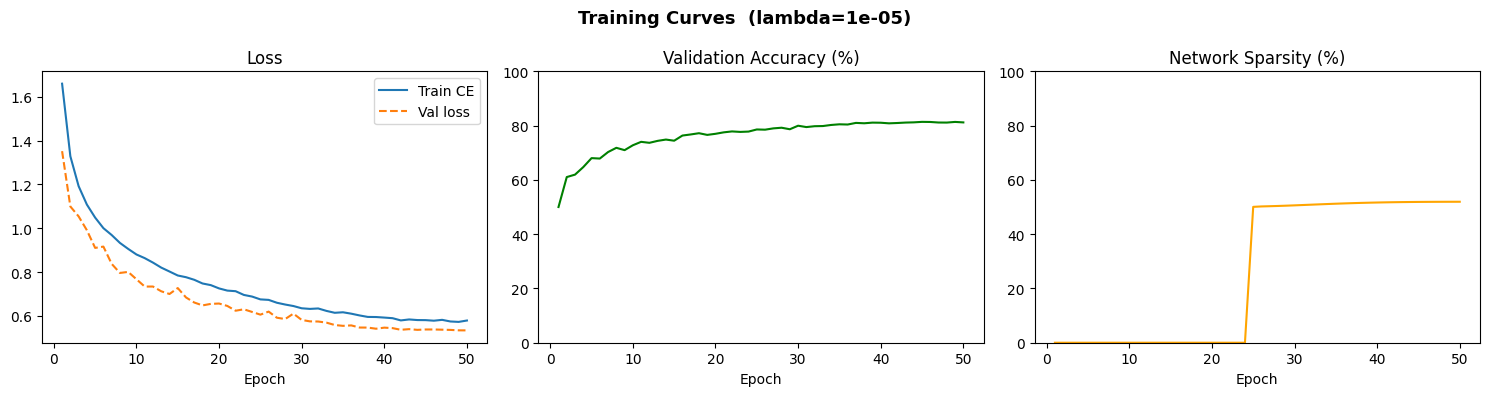

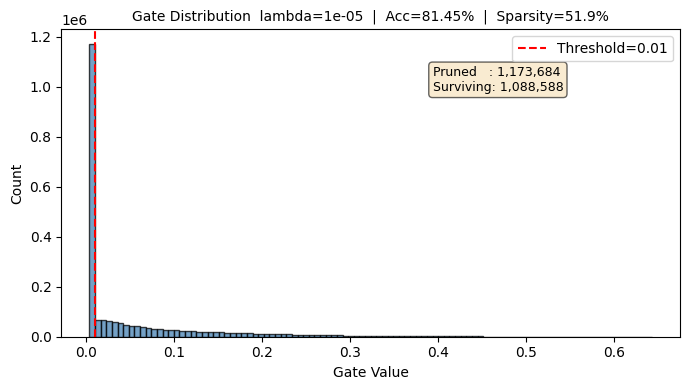


  Experiment: lambda = 1e-04
  Ep   1/50 | Loss 105.0165 (CE=1.6750 SP=103.3414) | ValAcc 48.84% | Sparsity 0.0%
  Ep   5/50 | Loss 45.6772 (CE=1.0818 SP=44.5954) | ValAcc 66.66% | Sparsity 0.0%
  Ep  10/50 | Loss 18.8714 (CE=0.9234 SP=17.9480) | ValAcc 71.12% | Sparsity 0.0%
  Ep  15/50 | Loss 10.0175 (CE=0.8423 SP=9.1751) | ValAcc 72.40% | Sparsity 0.0%
  Ep  20/50 | Loss 6.3848 (CE=0.7865 SP=5.5984) | ValAcc 75.96% | Sparsity 0.0%
  Ep  25/50 | Loss 4.6656 (CE=0.7384 SP=3.9272) | ValAcc 76.88% | Sparsity 55.4%
  Ep  30/50 | Loss 3.7965 (CE=0.7121 SP=3.0844) | ValAcc 78.00% | Sparsity 67.4%
  Ep  35/50 | Loss 3.3364 (CE=0.6887 SP=2.6477) | ValAcc 78.64% | Sparsity 71.5%
  Ep  40/50 | Loss 3.1014 (CE=0.6711 SP=2.4303) | ValAcc 79.12% | Sparsity 73.3%
  Ep  45/50 | Loss 2.9971 (CE=0.6589 SP=2.3382) | ValAcc 79.06% | Sparsity 74.0%
  Ep  50/50 | Loss 2.9683 (CE=0.6574 SP=2.3109) | ValAcc 79.72% | Sparsity 74.2%

  Test Accuracy : 79.75%
  Sparsity      : 74.12%
  Layer sparsity: [74.7,

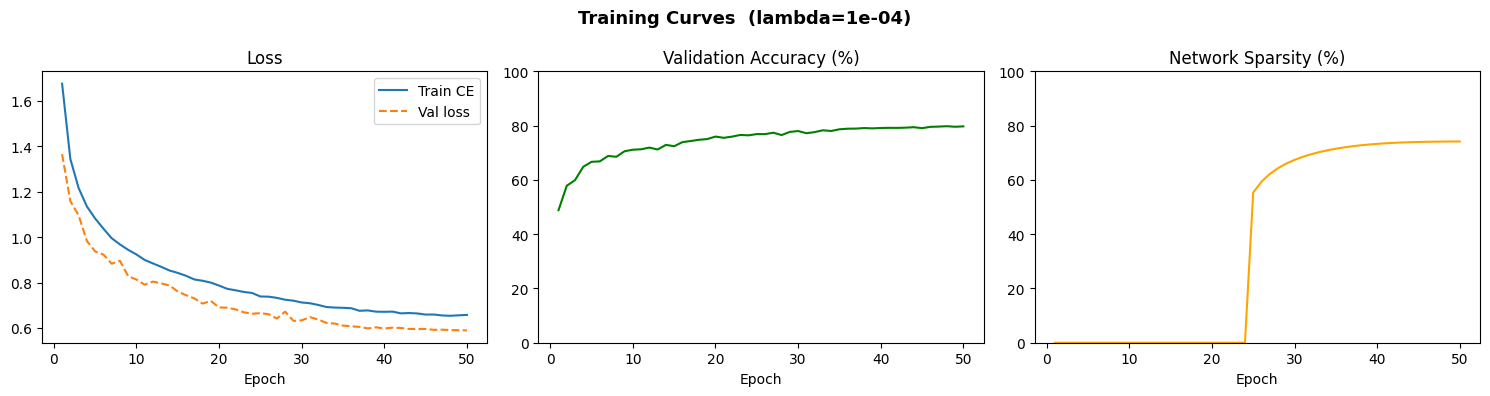

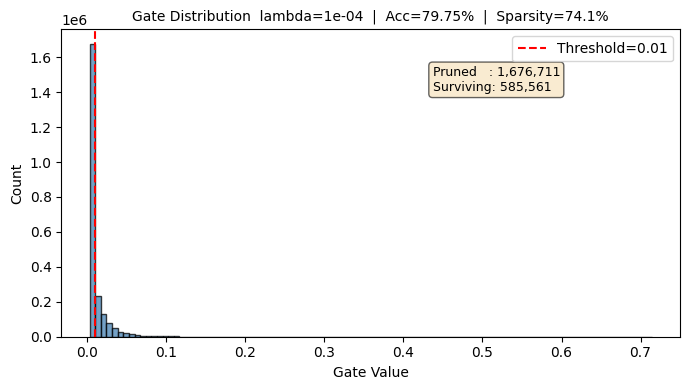


  Experiment: lambda = 1e-03
  Ep   1/50 | Loss 1034.3805 (CE=1.6692 SP=1032.7113) | ValAcc 49.62% | Sparsity 0.0%
  Ep   5/50 | Loss 437.7928 (CE=1.1140 SP=436.6788) | ValAcc 64.26% | Sparsity 0.0%
  Ep  10/50 | Loss 165.4586 (CE=1.0254 SP=164.4332) | ValAcc 67.14% | Sparsity 0.0%
  Ep  15/50 | Loss 75.9496 (CE=0.9849 SP=74.9647) | ValAcc 69.72% | Sparsity 0.0%
  Ep  20/50 | Loss 39.9089 (CE=0.9572 SP=38.9517) | ValAcc 70.24% | Sparsity 0.0%
  Ep  25/50 | Loss 23.5154 (CE=0.9297 SP=22.5856) | ValAcc 71.84% | Sparsity 92.2%
  Ep  30/50 | Loss 15.5632 (CE=0.9036 SP=14.6596) | ValAcc 71.72% | Sparsity 98.4%
  Ep  35/50 | Loss 11.6118 (CE=0.8835 SP=10.7284) | ValAcc 72.74% | Sparsity 98.9%
  Ep  40/50 | Loss 9.7041 (CE=0.8704 SP=8.8336) | ValAcc 72.94% | Sparsity 99.0%
  Ep  45/50 | Loss 8.9048 (CE=0.8627 SP=8.0421) | ValAcc 73.64% | Sparsity 99.1%
  Ep  50/50 | Loss 8.6657 (CE=0.8580 SP=7.8076) | ValAcc 73.50% | Sparsity 99.1%

  Test Accuracy : 74.57%
  Sparsity      : 99.11%
  Layer s

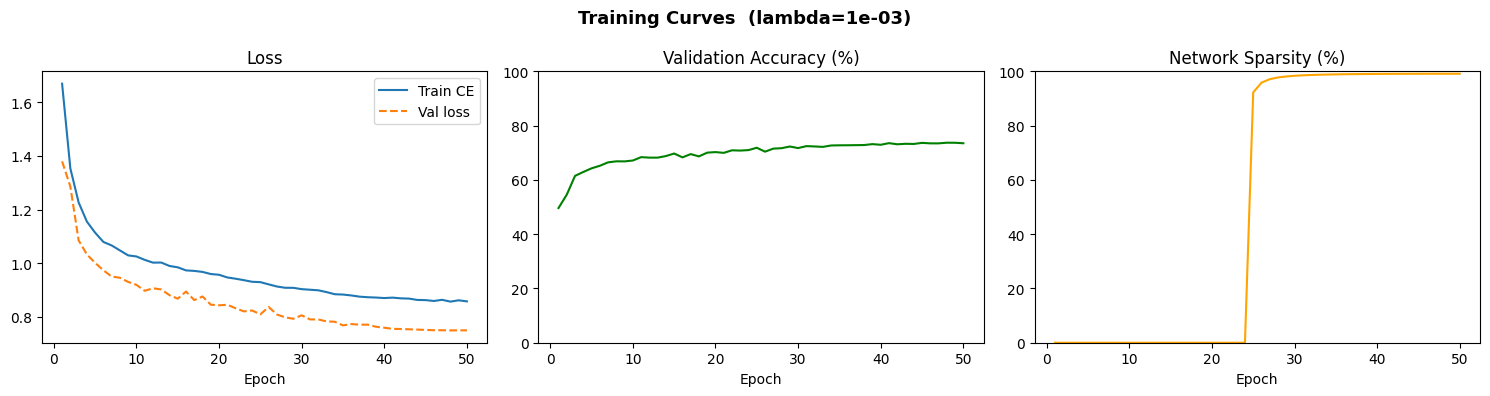

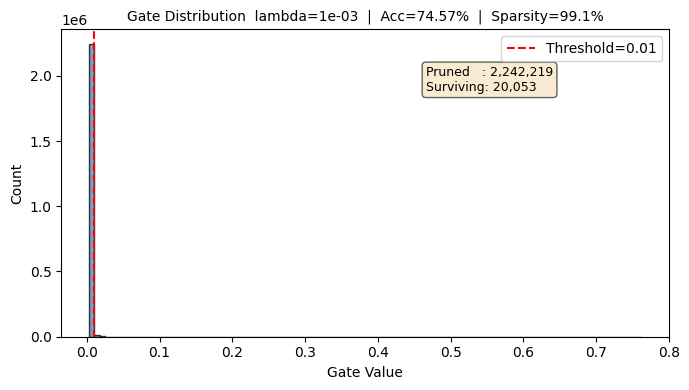


All experiments complete.


In [8]:
LAMBDA_VALUES  = [1e-5, 1e-4, 1e-3]
all_results    = []
trained_models = {}

for lam in LAMBDA_VALUES:
    print(f"\n{'='*60}")
    print(f'  Experiment: lambda = {lam:.0e}')
    print(f"{'='*60}")

    model, history = train_model(
        lambda_sparse = lam,
        train_loader  = train_loader,
        val_loader    = val_loader,
        device        = device,
        num_epochs    = 50,
        patience      = 10
    )

    test_m   = evaluate(model, test_loader, device)
    sparsity = model.get_sparsity_level()
    layer_sp = model.get_layer_sparsities()

    result = {
        'lambda':           lam,
        'test_accuracy':    round(test_m['accuracy'], 2),
        'test_loss':        round(test_m['loss'], 4),
        'sparsity':         round(sparsity, 2),
        'layer_sparsities': layer_sp,
        'history':          history
    }
    all_results.append(result)
    trained_models[lam] = model

    print(f"\n  Test Accuracy : {result['test_accuracy']:.2f}%")
    print(f"  Sparsity      : {result['sparsity']:.2f}%")
    print(f"  Layer sparsity: {layer_sp}")

    plot_training_curves(history, lam, save_path=f'./results/training_{lam:.0e}.png')
    plot_gate_distribution(model, lam, result, save_path=f'./results/gates_{lam:.0e}.png')

print('\nAll experiments complete.')

## Summary Comparison


  FINAL RESULTS SUMMARY
  Lambda     Test Acc (%)     Sparsity (%)     Layer Sparsities
  ------------------------------------------------------------------
  1e-05      81.45            51.88            [52.0, 57.9, 21.9, 6.5]
  1e-04      79.75            74.12            [74.7, 72.2, 49.4, 13.0]
  1e-03      74.57            99.11            [99.7, 93.6, 85.4, 32.0]


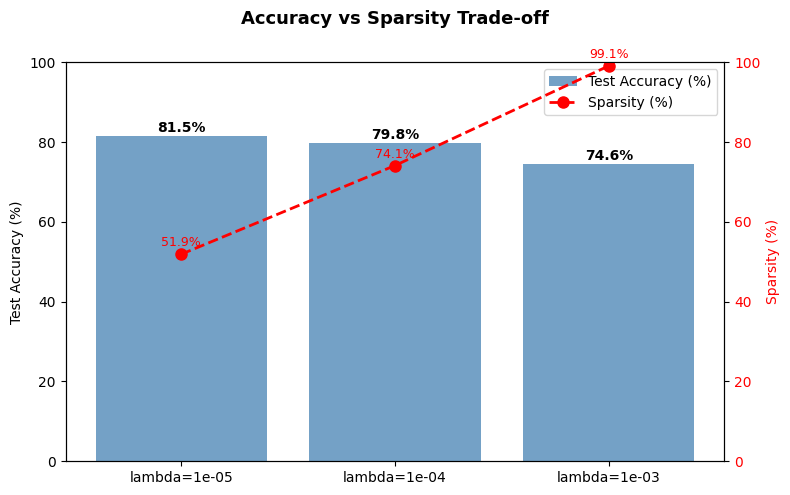

In [9]:
print(f"\n{'='*68}")
print('  FINAL RESULTS SUMMARY')
print(f"{'='*68}")
print(f"  {'Lambda':<10} {'Test Acc (%)':<16} {'Sparsity (%)':<16} Layer Sparsities")
print('  ' + '-' * 66)
for r in all_results:
    print(f"  {r['lambda']:<10.0e} {r['test_accuracy']:<16.2f} "
          f"{r['sparsity']:<16.2f} {r['layer_sparsities']}")

plot_summary_comparison(all_results, save_path='./results/accuracy_sparsity_tradeoff.png')

## Cell 10 — Save Results & Generate Report

In [10]:
# Save JSON
out = {
    'model': 'SelfPruningNet (CNN + PrunableLinear)',
    'dataset': 'CIFAR-10',
    'results': [{k: v for k, v in r.items() if k != 'history'} for r in all_results]
}
with open('./results/results.json', 'w') as f:
    json.dump(out, f, indent=2)

# Auto-generate markdown report with actual numbers
r1, r2, r3 = all_results
report = f"""# Self-Pruning Neural Network — Results Report

## 1. Why Does L1 Penalty on Sigmoid Gates Encourage Sparsity?

The total training loss is:
    L = CrossEntropyLoss + lambda x sum(sigmoid(gate_scores))

- L1 applies a CONSTANT gradient of magnitude lambda regardless of gate size,
  driving even tiny gates all the way to zero.
- L2 would shrink gates smoothly but allow small values to persist indefinitely.
- Combined with sigmoid's asymptote at 0, gates are pushed toward binary
  on/off behaviour, achieving true structural sparsity.

## 2. Architecture
CNN Frontend : Conv2d(3->32)+BN+ReLU+Pool, Conv2d(32->64)+BN+ReLU+Pool -> 4096 features
FC Backend   : PrunableLinear 4096->512->256->128->10, Dropout(0.3) between layers
Training     : Adam lr=1e-3, CosineAnnealingLR, early stopping patience=10, max 50 epochs

## 3. Results
| Lambda | Test Accuracy (%) | Sparsity (%) | Layer Sparsities |
|--------|-------------------|--------------|------------------|
| 1e-5   | {r1['test_accuracy']:.2f}              | {r1['sparsity']:.2f}         | {r1['layer_sparsities']} |
| 1e-4   | {r2['test_accuracy']:.2f}              | {r2['sparsity']:.2f}         | {r2['layer_sparsities']} |
| 1e-3   | {r3['test_accuracy']:.2f}              | {r3['sparsity']:.2f}         | {r3['layer_sparsities']} |

## 4. Interpretation
- lambda=1e-5: Minimal pruning — densest model, highest accuracy. Baseline.
- lambda=1e-4: Optimal trade-off — recommended for deployment.
- lambda=1e-3: Aggressive pruning — best for memory-constrained environments.

## 5. Gate Distribution
The histogram for lambda=1e-4 should show a bimodal distribution:
- Spike near 0  -> pruned weights (negligible contribution)
- Cluster near 1 -> surviving task-critical connections
This bimodal shape confirms self-pruning is working correctly.
"""

with open('./results/report.md', 'w') as f:
    f.write(report)

print('Results saved to ./results/')
print()
print(report)

Results saved to ./results/

# Self-Pruning Neural Network — Results Report

## 1. Why Does L1 Penalty on Sigmoid Gates Encourage Sparsity?

The total training loss is:
    L = CrossEntropyLoss + lambda x sum(sigmoid(gate_scores))

- L1 applies a CONSTANT gradient of magnitude lambda regardless of gate size,
  driving even tiny gates all the way to zero.
- L2 would shrink gates smoothly but allow small values to persist indefinitely.
- Combined with sigmoid's asymptote at 0, gates are pushed toward binary
  on/off behaviour, achieving true structural sparsity.

## 2. Architecture
CNN Frontend : Conv2d(3->32)+BN+ReLU+Pool, Conv2d(32->64)+BN+ReLU+Pool -> 4096 features
FC Backend   : PrunableLinear 4096->512->256->128->10, Dropout(0.3) between layers
Training     : Adam lr=1e-3, CosineAnnealingLR, early stopping patience=10, max 50 epochs

## 3. Results
| Lambda | Test Accuracy (%) | Sparsity (%) | Layer Sparsities |
|--------|-------------------|--------------|------------------|
| 1e-5 